# 10. Morphological Operations

## Table of Contents
1. [Libraries](#libraries)
2. [Erosion](#erosion)
3. [Dilation](#dilation)
4. [Opening](#opening)
5. [Closing](#closing)
6. [Morphological Gradient](#gradient)
7. [Morphological Hats](#hats)
   1. [Top or White Hat](#top)
   1. [Black Hat](#black)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("data/image.jpg")
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2 = cv2.imread("data/image.jpg",0)

(430, 900, 3) (430, 900, 3) (430, 900)


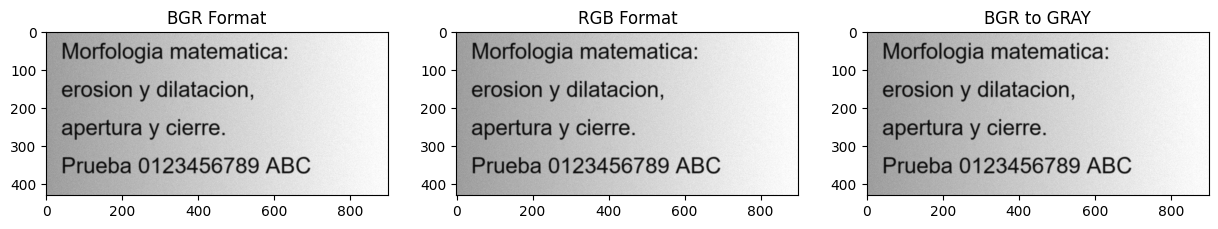

In [3]:
#function to see image
def imgshow(img=img,img1=img1,img2=img2, rows=1,columns=3):
    print(img.shape,img1.shape,img2.shape)
    fig = plt.figure(figsize=(15,8))
    #adds a subplot at 1st position
    fig.add_subplot(rows,columns,1)
    plt.title('BGR Format')
    plt.imshow(img)

    #adds a subplot at 2nd position
    fig.add_subplot(rows,columns,2)
    plt.title('RGB Format')
    plt.imshow(img1)

    #adds a subplot at 3rd position
    fig.add_subplot(rows,columns, 3)
    plt.title('BGR to GRAY')
    plt.imshow(img2,cmap="gray")
    plt.show()
    
imgshow(img=img,img1=img1,img2=img2, rows=1,columns=3)

## Erosion <a class="anchor" id="erosion" ></a>

Erosin primarily involves eroding(thinning) outer surface(foreground) of image
- Tt is suggested to have foreground as white

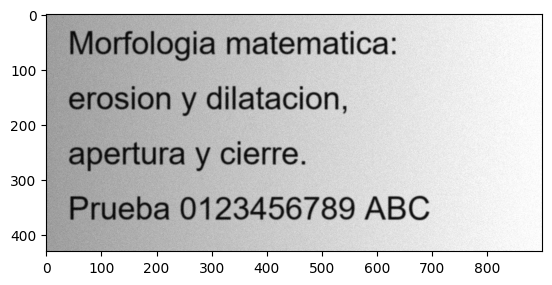

In [4]:
BGR2GRAY = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(BGR2GRAY,cmap="gray")
plt.show()

Eroding boundy of image upto 3 level

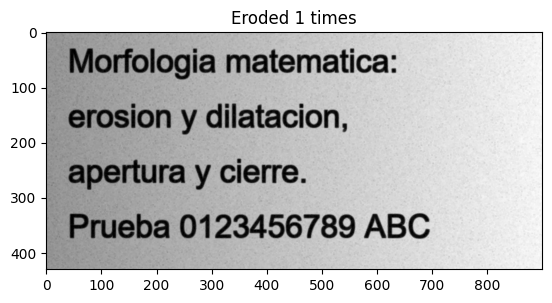

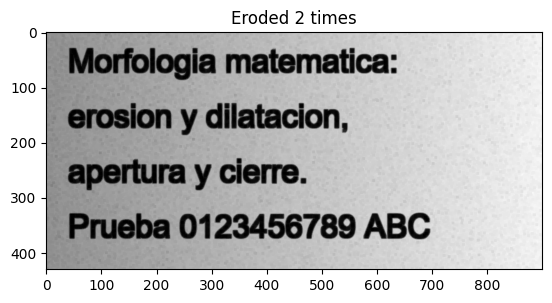

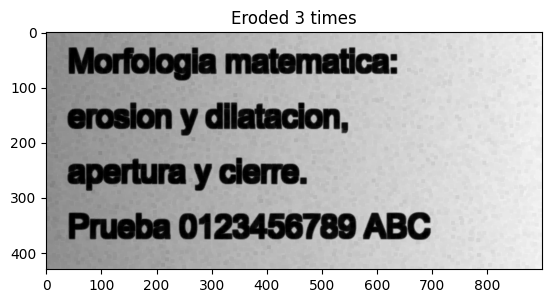

In [5]:
def plt_imshow(title, image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.title(title)
    plt.grid(False)
    plt.show()
    
for i in range(0,3):
    eroded = cv2.erode(BGR2GRAY.copy(), None, iterations=i+1)
    plt_imshow("Eroded {} times".format(i+1), eroded)

### Binarize Image

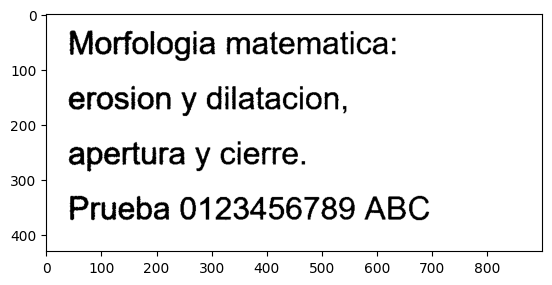

In [6]:
binr = cv2.threshold(BGR2GRAY, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
image = cv2.cvtColor(binr, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

### We can Invert Image to keep foreground in white

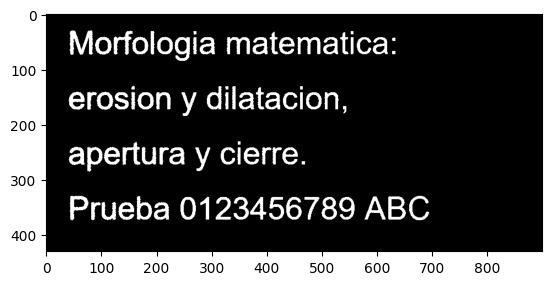

In [7]:
invert = cv2.bitwise_not(binr)
image = cv2.cvtColor(invert, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

Then, we can define a kernel of $5 \times 5$ to use in erosion

In [8]:
kernel = np.ones((5,5), np.uint8) #check for 3*3 or 7*7 kernel size too
print(kernel)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


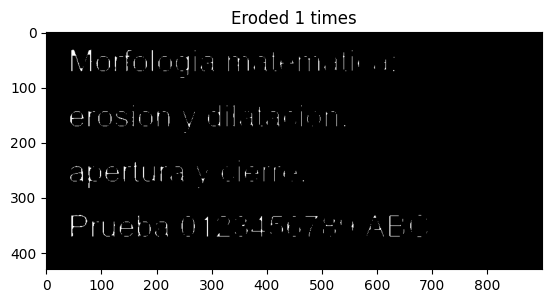

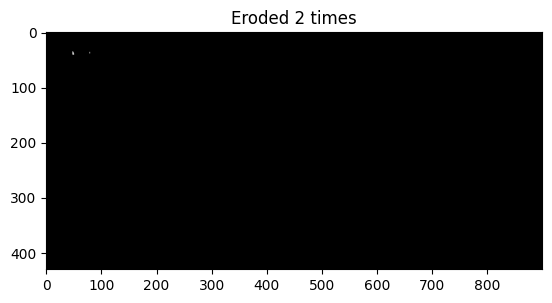

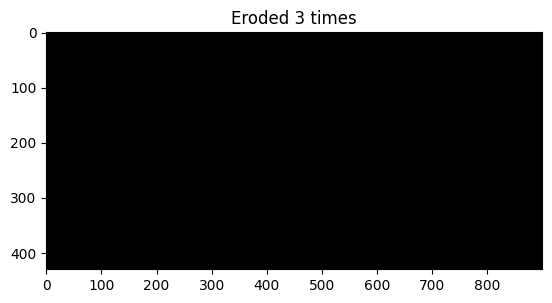

In [9]:
for i in range(0,3):
    eroded = cv2.erode(invert.copy(),kernel=kernel, iterations=i+1)
    plt_imshow("Eroded {} times".format(i+1), eroded)

## Dilation <a class="anchor" id="dilation" ></a>

Involves dilating outer surface (foreground) of image
- For joining broken parts of an image together

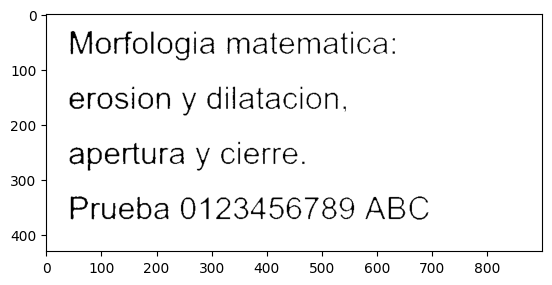

In [10]:
#binarize image
binr = cv2.threshold(BGR2GRAY,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
kernel = np.ones((3,3),np.uint8)
invert = cv2.bitwise_not(binr)

#dilate image
dilation = cv2.dilate(binr, kernel, iterations=1)
 
plt.imshow(dilation, cmap='gray')
plt.show()

We can apply series of dilations on inverted image using no kernel


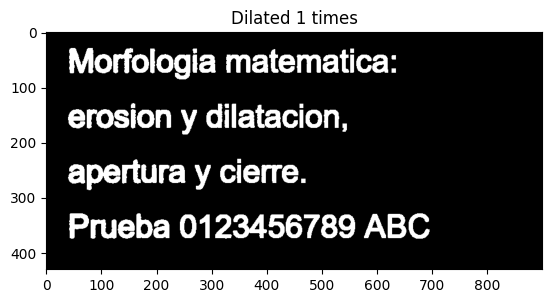

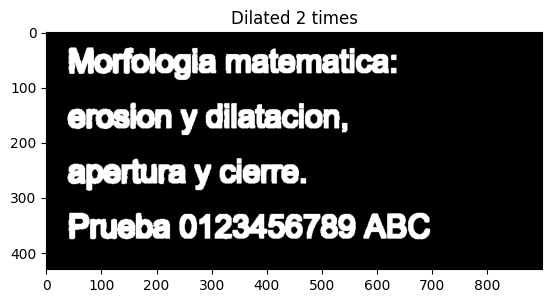

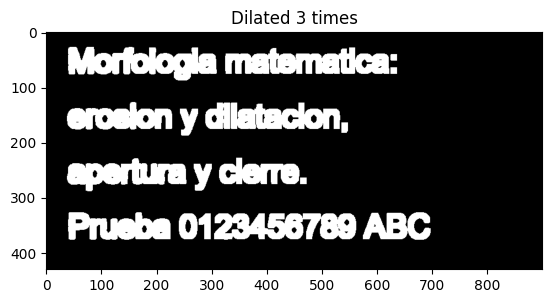

In [11]:
for i in range(0,3):
    dilated = cv2.dilate(invert.copy(),None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),dilated)

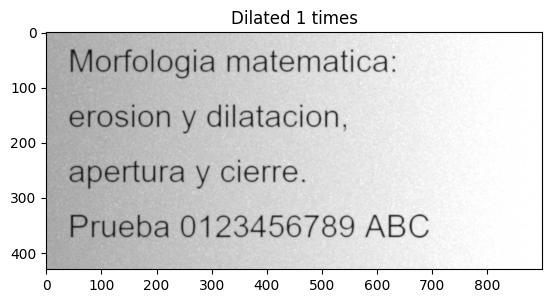

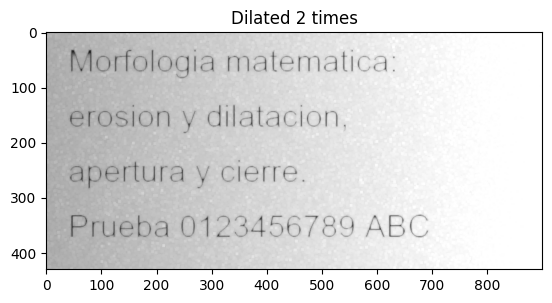

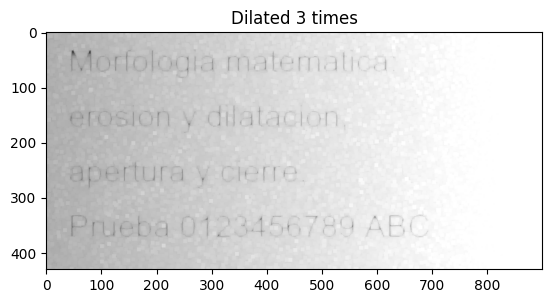

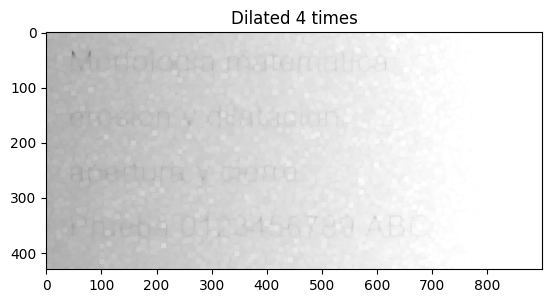

In [12]:
for i in range(0,4):
    dilated = cv2.dilate(BGR2GRAY.copy(),None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),dilated)

## Opening <a class="anchor" id="opening" ></a>

Erosion followed by dilation in outer surface (foreground) of image
- Generally used to remove noise (small blobs) in image


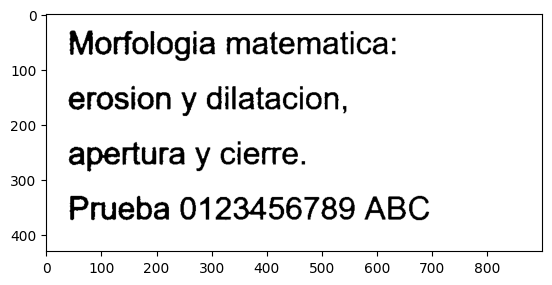

In [13]:
#opening image
opening = cv2.morphologyEx(binr,cv2.MORPH_OPEN,kernel,iterations=1)

#print output
plt.imshow(opening, cmap='gray')
plt.show()

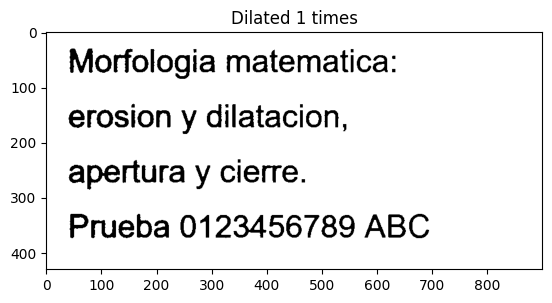

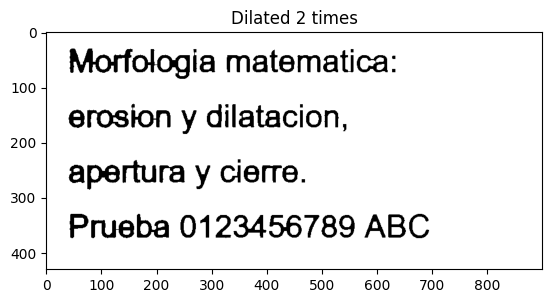

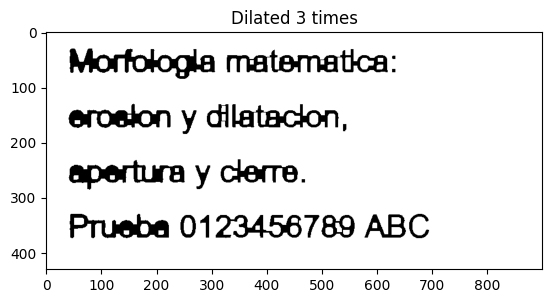

In [14]:
for i in range(0,3):
    opening = cv2.morphologyEx(binr.copy(),cv2.MORPH_OPEN,None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),opening)
    plt.show()

## Closing <a class="anchor" id="closing" ></a>

Dilation followed by erosion in outer surface (foreground) of image
- Generally used to close holes inside of objects or for connecting components together

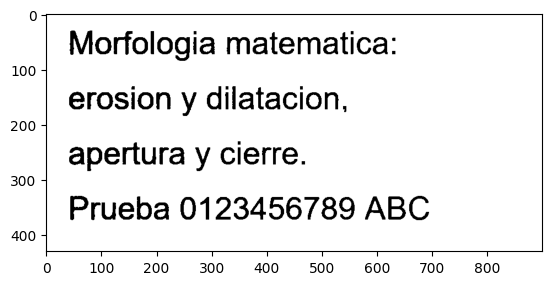

In [15]:
#closing image
closing = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel, iterations=1)
 
#print output
plt.imshow(closing,cmap='gray')
plt.show()

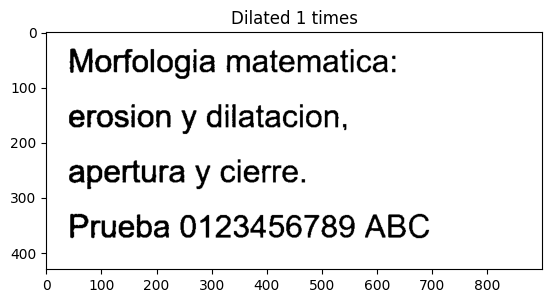

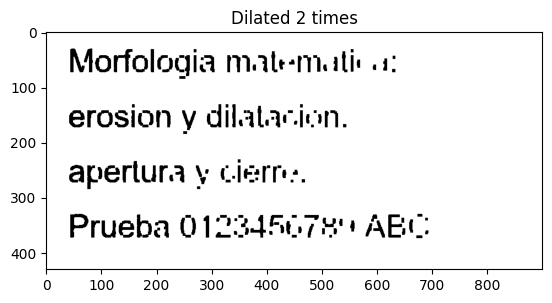

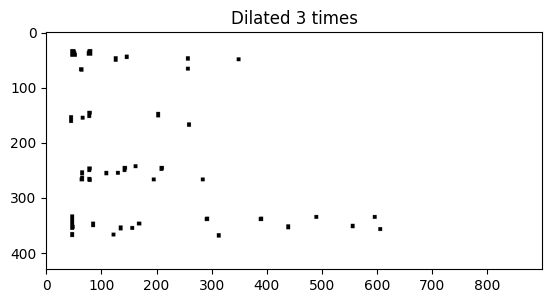

In [16]:
for i in range(0,3):
    closing = cv2.morphologyEx(binr.copy(),cv2.MORPH_CLOSE,None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),closing)
    plt.show()

Iterating with different kernels

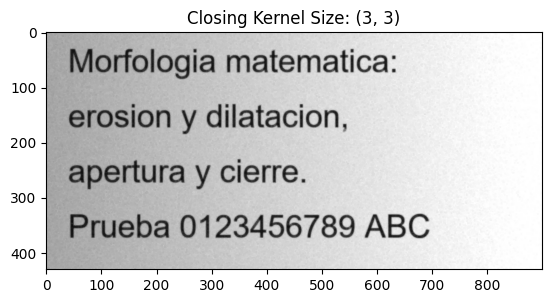

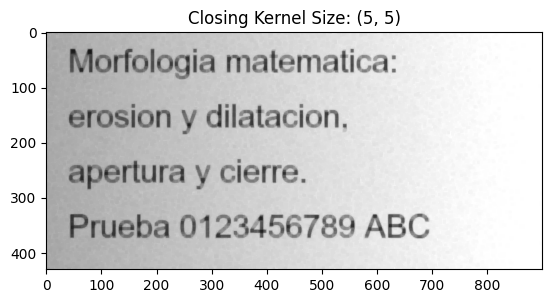

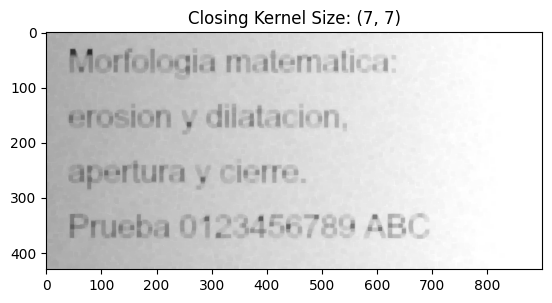

In [17]:
kernelSizes = [(3,3), (5,5), (7,7)]
BGR2GRAY = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

for kernelSize in kernelSizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)
    closing = cv2.morphologyEx(BGR2GRAY, cv2.MORPH_CLOSE, kernel)
    plt_imshow("Closing Kernel Size: ({}, {})".format(kernelSize[0], kernelSize[1]), closing)

## Morphological Gradient <a class="anchor" id="gradient" ></a>

It first applies erosion and dilation individually on image and then computes difference between eroded and dilated image

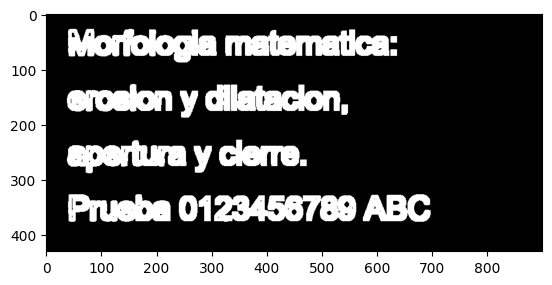

In [18]:
# use morph gradient
morph_gradient = cv2.morphologyEx(invert,cv2.MORPH_GRADIENT,kernel)
 
#print output
plt.imshow(morph_gradient, cmap='gray')
plt.show()

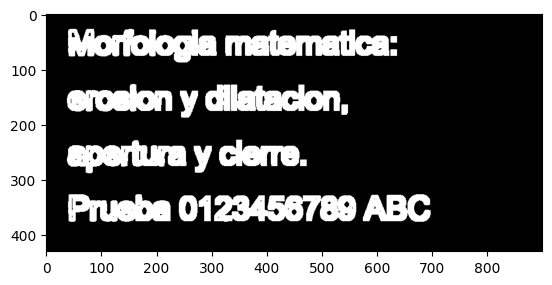

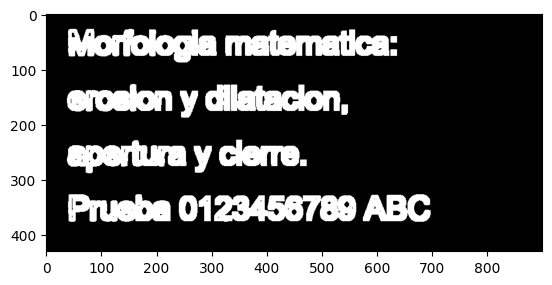

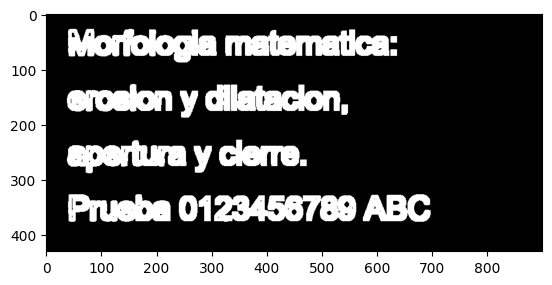

In [19]:
for i in range(0,3): 
    # use morph gradient
    morph_gradient = cv2.morphologyEx(invert,cv2.MORPH_GRADIENT,kernel+i)
    #print output
    plt.imshow(morph_gradient, cmap='gray')
    plt.show()

Iterating with different kernels

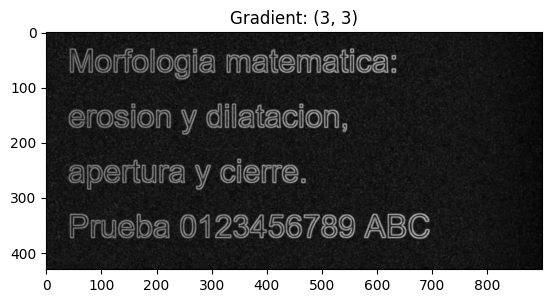

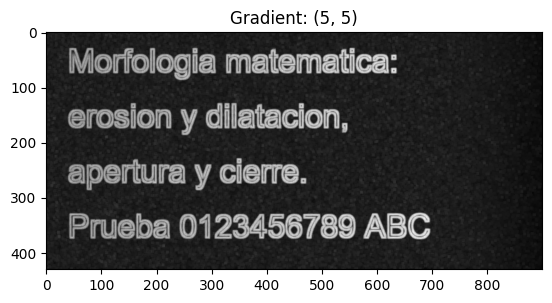

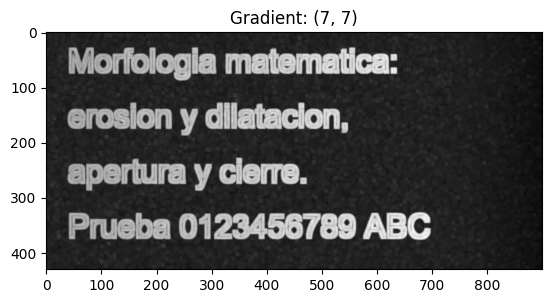

In [20]:
kernelSizes = [(3,3), (5,5), (7,7)]
BGR2GRAY = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

for kernelSize in kernelSizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)
    gradient = cv2.morphologyEx(BGR2GRAY, cv2.MORPH_GRADIENT, kernel)
    plt_imshow("Gradient: ({}, {})".format(
        kernelSize[0], kernelSize[1]), gradient)

## Morphological Hats <a class="anchor" id="hats" ></a>

1. Top or White Hat
2. Black hat

### Top or White Hat <a class="anchor" id="top" ></a>

It is the difference between original (grayscale/single channel) input image and opening image

- Finds light(bright) regions of an image on dark background


In [21]:
#construct a kernel (13x5)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(13,5))
kernel

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=uint8)

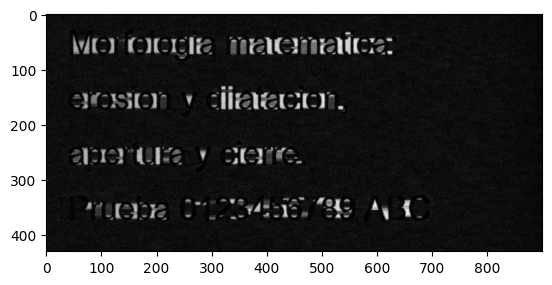

In [22]:
tophat = cv2.morphologyEx(BGR2GRAY, cv2.MORPH_TOPHAT, kernel)

plt.imshow(tophat, cmap='gray')
plt.show()

### Black Hat <a class="anchor" id="black" ></a>

Output is a difference between input image & opened image
- Finds dark regions on a light background


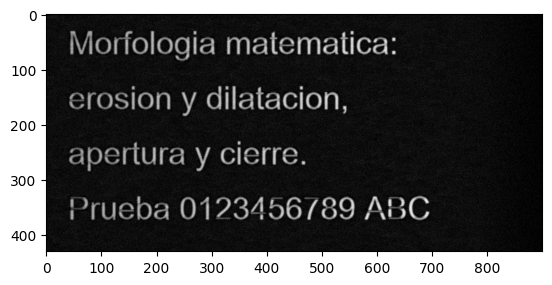

In [23]:
blackhat = cv2.morphologyEx(BGR2GRAY,cv2.MORPH_BLACKHAT,kernel)

plt.imshow(blackhat, cmap='gray')
plt.show()

# Ejercicios de la actividad

Los tres ejercicios aplican la morfología a problemas concretos y se **miden** con métricas objetivas (conteos y coincidencia con una máscara conocida).
La imagen del notebook base (`data/image.jpg`) es una hoja de texto escaneada con iluminación desigual y ruido, generada con texto propio; los núcleos celulares son una fotografía real de microscopía de fluorescencia (CC BY-SA 4.0, ver `LICENCIAS.md`).

1. [Ejercicio 1: erosión para separar y contar objetos que se tocan](#ej1)
2. [Ejercicio 2: dilatación para reparar trazos rotos](#ej2)
3. [Ejercicio 3: apertura y cierre para limpiar un documento](#ej3)
4. [Conclusión](#conclusion)

<a id="ej1"></a>
## Ejercicio 1. Aplicación de la erosión: separar núcleos celulares que se tocan y contarlos

**Investigación.** La erosión de un objeto binario $A$ con un elemento estructurante $B$ es $A \ominus B = \{z \mid B_z \subseteq A\}$: solo sobreviven los píxeles donde $B$ cabe completo dentro del objeto.
Elimina detalles menores que $B$ y **desconecta objetos unidos por puentes delgados** (Gonzalez & Woods, 2018, cap. 9). En biología y microscopía se emplea para separar células o núcleos que se tocan antes de contarlos o medirlos;
si los objetos se cuentan tal cual, los que se tocan forman un solo componente conexo y el conteo se subestima.

**Demo.** Se cuentan los núcleos de una imagen de fluorescencia (DAPI, canal verde): umbral de Otsu → componentes conexos, y luego después de $k$ iteraciones de erosión con un elemento de 3×3 en forma de elipse.
Como referencia independiente se usa el conteo por máximos locales de la transformada de distancia, una técnica estándar de separación.

 iteraciones  objetos contados  área (píxeles)
           0               125           60506
           1               125           51757
           2               125           43574
           3               127           36040
           4               120           29190
           5               116           22988
           6               119           17438

Referencia (máximos de la transformada de distancia): 132 núcleos


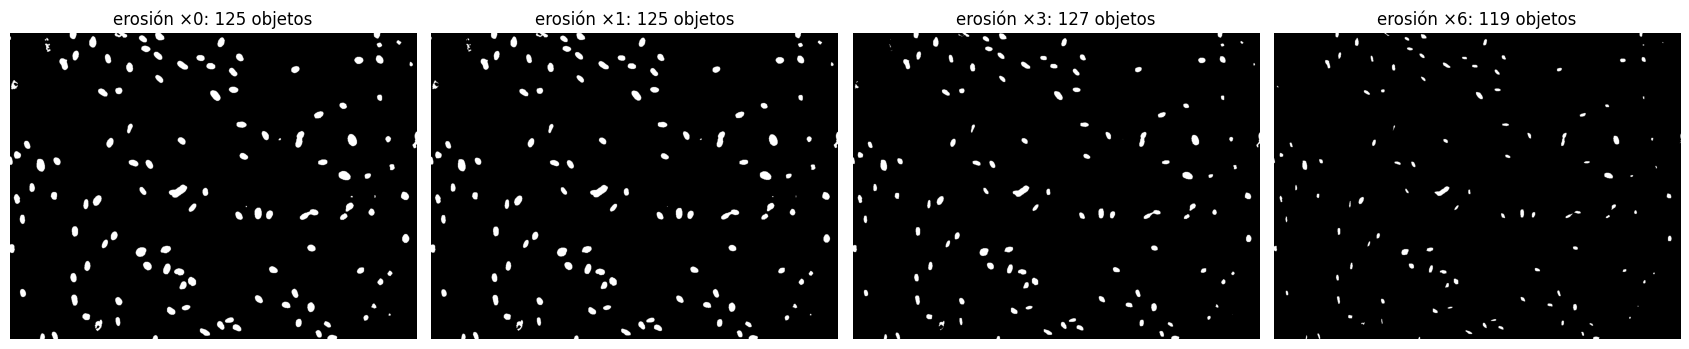

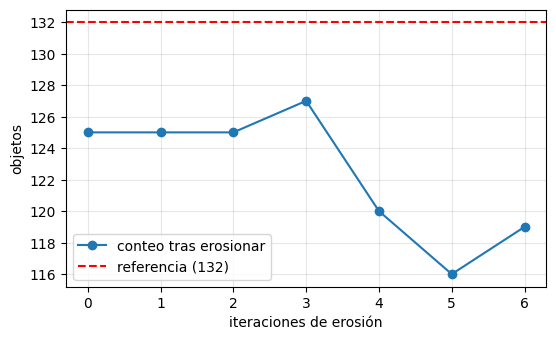

In [24]:
import cv2, numpy as np, matplotlib.pyplot as plt
from skimage.feature import peak_local_max

def contar(mascara):
    n, etiquetas = cv2.connectedComponents((mascara > 0).astype(np.uint8), connectivity=8)
    return n - 1, etiquetas

im = cv2.imread("data/nucleos.png")
verde = im[..., 1]
_, nucleos = cv2.threshold(cv2.GaussianBlur(verde, (3, 3), 0), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
nucleos = cv2.morphologyEx(nucleos, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))   # quita puntos aislados de ruido

el = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
iteraciones = list(range(0, 7))
conteos, areas = [], []
for k in iteraciones:
    e = cv2.erode(nucleos, el, iterations=k) if k else nucleos
    conteos.append(contar(e)[0]); areas.append(int((e > 0).sum()))

# Referencia independiente: máximos de la transformada de distancia
dist = cv2.distanceTransform((nucleos > 0).astype(np.uint8), cv2.DIST_L2, 5)
picos = peak_local_max(dist, min_distance=6, threshold_abs=3, labels=(nucleos > 0).astype(int))
ref = len(picos)

print(f"{'iteraciones':>12s} {'objetos contados':>17s} {'área (píxeles)':>15s}")
for k, c, a in zip(iteraciones, conteos, areas): print(f"{k:12d} {c:17d} {a:15d}")
print(f"\nReferencia (máximos de la transformada de distancia): {ref} núcleos")

fig, ejes = plt.subplots(1, 4, figsize=(17, 4.6))
for a, k in zip(ejes, (0, 1, 3, 6)):
    e = cv2.erode(nucleos, el, iterations=k) if k else nucleos
    a.imshow(e, cmap="gray"); a.set_title(f"erosión ×{k}: {contar(e)[0]} objetos"); a.axis("off")
plt.tight_layout(); plt.show()
plt.figure(figsize=(6.2, 3.6)); plt.plot(iteraciones, conteos, "o-", label="conteo tras erosionar"); plt.axhline(ref, color="r", ls="--", label=f"referencia ({ref})")
plt.xlabel("iteraciones de erosión"); plt.ylabel("objetos"); plt.legend(); plt.grid(alpha=.3); plt.show()


**Resultados y discusión.**
- Sin erosionar se cuentan 125 núcleos; con 3 iteraciones el conteo sube a 127 y después baja (120, 116 y 119). La referencia por transformada de distancia da 132.
- La erosión separó pocos núcleos: en esta imagen son escasos los que se tocan (unos 7 de 132 según la referencia). A cambio, el área de primer plano cae de 60 506 a 36 040 píxeles (−40 %) con 3 iteraciones y a 17 438 (−71 %) con 6, y los núcleos pequeños desaparecen por completo, de ahí que el conteo descienda después de la tercera iteración.
- Es el compromiso característico de la erosión: cuanto más se erosiona, mejor se separan los objetos unidos, pero se pierden los más pequeños. Un elemento estructurante fijo trata igual a todos los objetos; la transformada de distancia (base del método *watershed*) adapta la separación al tamaño de cada uno y dio el conteo más alto.
  La erosión es adecuada cuando los objetos tienen tamaño parecido y están unidos por puentes delgados; no cuando hay mucha variación de tamaño.


<a id="ej2"></a>
## Ejercicio 2. Aplicación de la dilatación: reparar trazos rotos (preprocesamiento para OCR)

**Investigación.** La dilatación $A \oplus B$ engrosa los objetos y **cierra huecos y grietas** más estrechos que el elemento estructurante (Gonzalez & Woods, 2018, cap. 9).
Una aplicación clásica es el **reconocimiento óptico de caracteres (OCR)** sobre documentos impresos o escaneados de baja calidad: los trazos rotos por el ruido o por la impresión se reconectan para que cada carácter sea un solo objeto.
El riesgo es el opuesto a la erosión: si se dilata demasiado, caracteres vecinos se fusionan.

**Demo.** Sobre un texto limpio se abren huecos aleatorios de 2–3 píxeles en los trazos (con semilla fija) y se dilata con 0 a 4 iteraciones. Se cuentan los componentes conexos (cada carácter debería ser uno, salvo *i* y *j*, que tienen dos) y se mide la coincidencia (IoU) con el texto original.

Componentes en el texto limpio: 80    en el texto roto: 137
 dilataciones  componentes  IoU con el original
            0          137                0.943
            1           80                0.665
            2           63                0.498
            3           24                0.401
            4           15                0.344


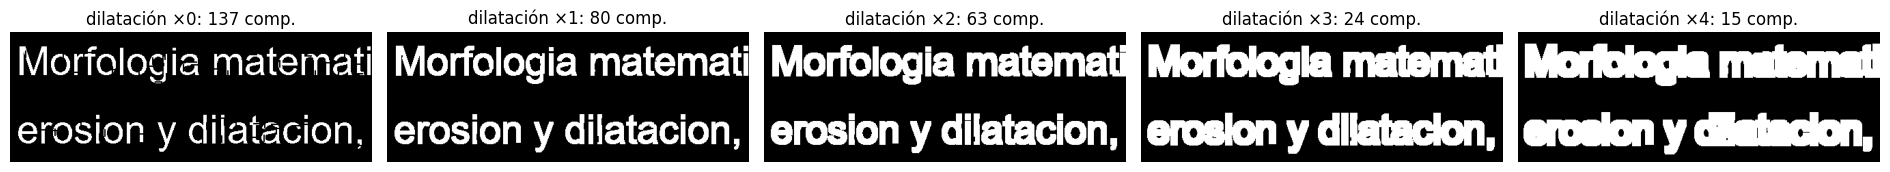

cierre ×1: componentes   80, IoU 0.971
cierre ×2: componentes   69, IoU 0.941
cierre ×3: componentes   29, IoU 0.850


In [25]:
limpio = (cv2.imread("data/documento_limpio.png", 0) < 128).astype(np.uint8) * 255          # texto en blanco sobre negro
rng = np.random.default_rng(5)

def romper(mask, n=120):
    # cortes que atraviesan el trazo: líneas de 2 px de ancho y 11 px de largo, horizontales o verticales
    out = mask.copy(); ys, xs = np.nonzero(mask)
    for i in rng.choice(len(ys), n, replace=False):
        y, x = ys[i], xs[i]
        if rng.random() < .5: out[y - 5:y + 6, x:x + 2] = 0
        else: out[y:y + 2, x - 5:x + 6] = 0
    return out

roto = romper(limpio)
def iou(a, b): return float(((a > 0) & (b > 0)).sum() / max(((a > 0) | (b > 0)).sum(), 1))

k3 = np.ones((3, 3), np.uint8)
print(f"Componentes en el texto limpio: {contar(limpio)[0]}    en el texto roto: {contar(roto)[0]}")
print(f"{'dilataciones':>13s} {'componentes':>12s} {'IoU con el original':>20s}")
fig, ejes = plt.subplots(1, 5, figsize=(19, 3.4))
for k, a in zip(range(5), ejes):
    d = cv2.dilate(roto, k3, iterations=k) if k else roto
    print(f"{k:13d} {contar(d)[0]:12d} {iou(d, limpio):20.3f}")
    a.imshow(d[10:200, 30:560], cmap="gray"); a.set_title(f"dilatación ×{k}: {contar(d)[0]} comp."); a.axis("off")
plt.tight_layout(); plt.show()
# Dilatar y luego erosionar (cierre) repara sin engrosar
for k in (1, 2, 3):
    c = cv2.morphologyEx(roto, cv2.MORPH_CLOSE, k3, iterations=k)
    print(f"cierre ×{k}: componentes {contar(c)[0]:4d}, IoU {iou(c, limpio):.3f}")


**Resultados y discusión.**
- El texto limpio tiene 80 componentes conexos; los 120 cortes elevan el conteo a 137. Una dilatación 3×3 (1 iteración) devuelve exactamente 80 componentes, pero el IoU con el original baja de 0.943 a 0.665 porque cada trazo engrosa un píxel por lado.
- Con más iteraciones empiezan a fusionarse letras vecinas: 63 componentes con 2 iteraciones (menos que los 80 reales), 24 con 3 y 15 con 4, y el IoU cae a 0.344. Con 2 iteraciones, que cierran huecos de hasta 4 px, ya se unen letras, lo que indica que el espacio entre ellas es de pocos píxeles.
- El **cierre** (dilatar y luego erosionar) repara igual de bien con 1 iteración (80 componentes) y **mejora** el IoU a 0.971, porque la erosión devuelve el grosor original al trazo. Con 2 y 3 iteraciones también empieza a fusionar letras (69 y 29 componentes).
- Regla práctica: el elemento estructurante debe ser mayor que el hueco que se quiere reparar (cortes de 2 px) y menor que el espacio entre objetos que se quieren mantener separados.


<a id="ej3"></a>
## Ejercicio 3. Aplicación de apertura y cierre: limpiar un documento binarizado

**Investigación.** La **apertura** $A \circ B = (A \ominus B) \oplus B$ (erosión seguida de dilatación) elimina objetos y salientes más pequeños que $B$ **sin encoger** el resto; el **cierre** $A \bullet B = (A \oplus B) \ominus B$ (dilatación seguida de erosión) rellena huecos y cierra fisuras más pequeñas que $B$ sin engrosar.
El par apertura-cierre es el paso de limpieza estándar tras una binarización: se aplica en OCR, en visión industrial (piezas con ruido) y en imagen médica (máscaras de segmentación con agujeros y motas) (Gonzalez & Woods, 2018; OpenCV, s. f.).

**Demo.** A la máscara de texto limpia se le agregan dos tipos de ruido reales de una binarización: **motas** aisladas en el fondo (ruido «sal») y **agujeros** dentro de los trazos (ruido «pimienta»). Se prueban apertura, cierre y sus combinaciones con elementos estructurantes de distinto tamaño, y se mide la coincidencia (IoU y F1) con la máscara limpia.

método                      IoU     F1  comp.
sin limpiar               0.895  0.945    649
apertura 3×3              0.876  0.934    131
cierre 3×3                0.926  0.961    642
apertura→cierre 3×3       0.886  0.940     99
cierre→apertura 3×3       0.959  0.979     83
apertura 5×5              0.623  0.768    283
cierre 5×5                0.917  0.957    626
apertura→cierre 5×5       0.647  0.786    167
cierre→apertura 5×5       0.878  0.935    120


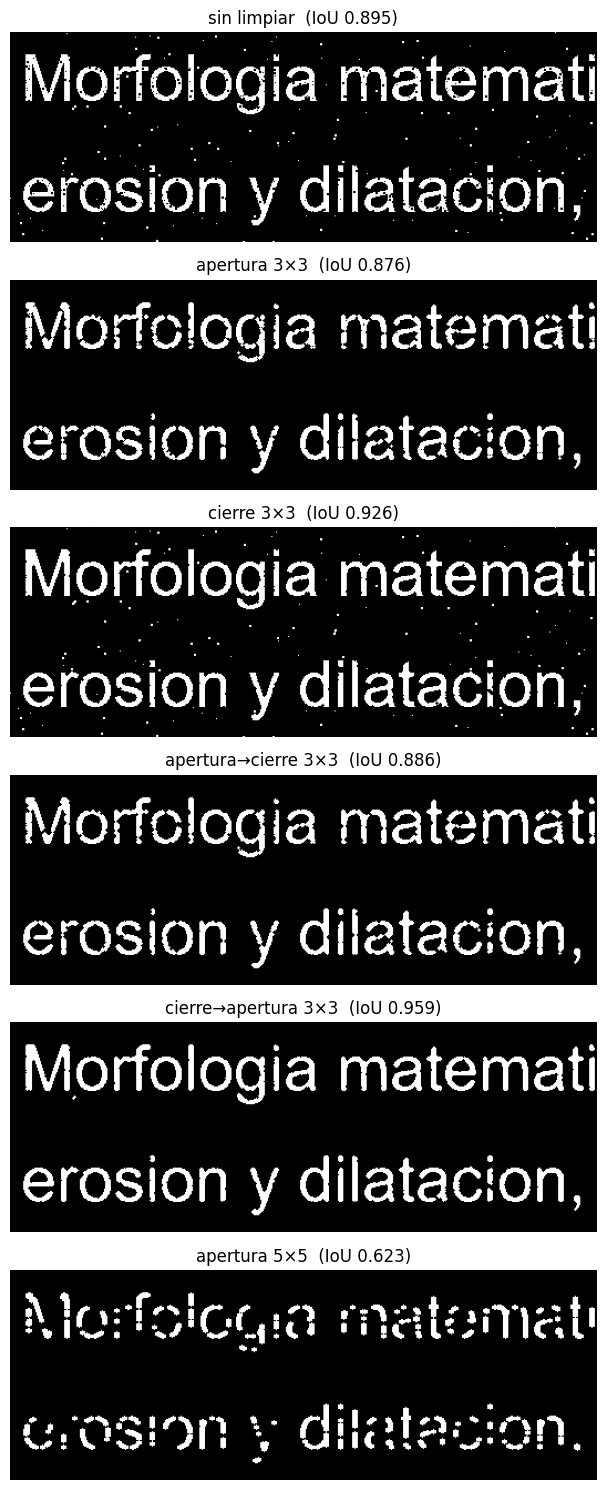

In [26]:
rng = np.random.default_rng(11)
def ensuciar(mask, motas=700, agujeros=700):
    out = mask.copy(); H, W = out.shape
    for _ in range(motas):                      # motas de 1-2 px en el fondo
        y, x = rng.integers(0, H - 3), rng.integers(0, W - 3); s = rng.integers(1, 3)
        if not mask[max(y - 3, 0):y + 4, max(x - 3, 0):x + 4].any(): out[y:y + s, x:x + s] = 255
    ys, xs = np.nonzero(mask)
    for i in rng.choice(len(ys), agujeros, replace=False):   # agujeros de 1-2 px dentro del texto
        s = rng.integers(1, 3); out[ys[i]:ys[i] + s, xs[i]:xs[i] + s] = 0
    return out

sucio = ensuciar(limpio)
def f1(a, b):
    tp = ((a > 0) & (b > 0)).sum(); fp = ((a > 0) & (b == 0)).sum(); fn = ((a == 0) & (b > 0)).sum()
    return float(2 * tp / max(2 * tp + fp + fn, 1))

def el(n): return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n, n))
casos = {"sin limpiar": sucio}
for n in (3, 5):
    casos[f"apertura {n}×{n}"] = cv2.morphologyEx(sucio, cv2.MORPH_OPEN, el(n))
    casos[f"cierre {n}×{n}"] = cv2.morphologyEx(sucio, cv2.MORPH_CLOSE, el(n))
    casos[f"apertura→cierre {n}×{n}"] = cv2.morphologyEx(cv2.morphologyEx(sucio, cv2.MORPH_OPEN, el(n)), cv2.MORPH_CLOSE, el(n))
    casos[f"cierre→apertura {n}×{n}"] = cv2.morphologyEx(cv2.morphologyEx(sucio, cv2.MORPH_CLOSE, el(n)), cv2.MORPH_OPEN, el(n))

print(f"{'método':24s} {'IoU':>6s} {'F1':>6s} {'comp.':>6s}")
for n, m in casos.items(): print(f"{n:24s} {iou(m, limpio):6.3f} {f1(m, limpio):6.3f} {contar(m)[0]:6d}")

sel = ["sin limpiar", "apertura 3×3", "cierre 3×3", "apertura→cierre 3×3", "cierre→apertura 3×3", "apertura 5×5"]
fig, ejes = plt.subplots(len(sel), 1, figsize=(11, 2.5 * len(sel)))
for a, n in zip(ejes, sel):
    a.imshow(casos[n][10:200, 30:560], cmap="gray"); a.set_title(f"{n}  (IoU {iou(casos[n], limpio):.3f})"); a.axis("off")
plt.tight_layout(); plt.show()


**Resultados y discusión.**
- El ruido deja 649 componentes (frente a 80 en el texto limpio) y un IoU de 0.895.
- La **apertura** 3×3 elimina las motas (131 componentes), pero al erosionar primero ensancha los agujeros y adelgaza los trazos: el IoU baja a 0.876, peor que sin limpiar. El **cierre** 3×3 rellena los agujeros (IoU 0.926) pero no toca las motas (642 componentes).
- **El orden importa.** **Cierre → apertura 3×3** da el mejor resultado (IoU 0.959, F1 0.979, 83 componentes, casi los 80 reales): primero se rellenan los agujeros, así la apertura ya no los ensancha, y después se eliminan las motas. Con el orden inverso (apertura → cierre) el IoU es de solo 0.886.
- **El elemento debe ser más pequeño que el detalle que se quiere conservar.** Con 5×5, comparable al grosor del trazo, la apertura destruye el texto (IoU 0.623) y la mejor combinación de 5×5 (0.878) queda por debajo de la de 3×3.
- Los elementos de tamaño par (2×2) no tienen centro y desplazan la imagen un píxel, por lo que se evitaron en la comparación.


<a id="conclusion"></a>
## Conclusión


- La **erosión** y la **dilatación** son las operaciones básicas; la apertura y el cierre se construyen combinándolas. Erosionar elimina detalles y separa objetos, dilatar engrosa y une; ninguna de las dos conserva el tamaño de los objetos, y cada una resuelve un problema a costa de crear el contrario.
- Los resultados medidos lo confirman: la erosión separó pocos núcleos y con 6 iteraciones borró el 71 % del área; la dilatación reparó los trazos rotos (80 componentes) pero bajó el IoU de 0.943 a 0.665; el cierre logró la misma reparación mejorando el IoU a 0.971.
- **Apertura y cierre son operaciones de «limpieza con memoria de tamaño»**: eliminan (apertura) o rellenan (cierre) lo que es menor que el elemento estructurante sin alterar el resto. Por eso el tamaño del elemento debe elegirse entre el detalle que se quiere quitar y el detalle que se quiere conservar (aquí, entre 2 px de ruido y 5 px de grosor del trazo).
- El **orden de las operaciones** cambió el resultado de forma apreciable: cierre → apertura obtuvo IoU 0.959 frente a 0.886 de apertura → cierre con el mismo elemento.
- La morfología es un paso de preprocesamiento barato y explicable que se combina con la binarización (Otsu) y con el análisis de componentes conexos; los conteos y el IoU permiten elegir los parámetros con criterio en lugar de hacerlo a ojo.
- Limitaciones: el texto y el ruido son sintéticos (con semilla fija), lo que permite conocer la verdad pero no reproduce toda la variedad de un documento real; el ejercicio de la erosión usa una sola imagen con pocos núcleos en contacto.


## Referencias

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson. (Cap. 9: Morphological image processing.)
- Serra, J. (1982). *Image analysis and mathematical morphology*. Academic Press.
- Haralick, R. M., Sternberg, S. R., & Zhuang, X. (1987). Image analysis using mathematical morphology. *IEEE Transactions on Pattern Analysis and Machine Intelligence, PAMI-9*(4), 532–550. https://doi.org/10.1109/TPAMI.1987.4767941
- Otsu, N. (1979). A threshold selection method from gray-level histograms. *IEEE Transactions on Systems, Man, and Cybernetics, 9*(1), 62–66. https://doi.org/10.1109/TSMC.1979.4310076
- OpenCV. (s. f.). *Morphological transformations* [Tutorial]. https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
- Rosebrock, A. (2021, 28 de abril). OpenCV morphological operations. *PyImageSearch*. https://pyimagesearch.com/2021/04/28/opencv-morphological-operations
- Bradski, G. (2000). The OpenCV library. *Dr. Dobb's Journal of Software Tools, 25*(11), 120–123.
- van der Walt, S., Schönberger, J. L., Nunez-Iglesias, J., Boulogne, F., Warner, J. D., Yager, N., Gouillart, E., & Yu, T. (2014). scikit-image: Image processing in Python. *PeerJ, 2*, e453. https://doi.org/10.7717/peerj.453
- Imágenes: documento generado con texto propio; microscopía de fluorescencia de Arnatbio (CC BY-SA 4.0), ver `LICENCIAS.md`.